In [2]:
from extractor import PDBBindProcessor
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
processor = PDBBindProcessor()
processor.extract_subset("refined")

df_refined = processor.build_dataset(subset="refined")
df_refined.to_csv("pdbbind_refined.csv", index=False)

df_core = processor.build_dataset(subset="core")
df_core.to_csv("pdbbind_core.csv", index=False)

Распаковка 4057 комплексов из refined...


66444it [01:20, 822.75it/s] 


Распаковка завершена.
Параллельный парсинг (8 ядер)...


100%|██████████| 4057/4057 [05:24<00:00, 12.52it/s]


Параллельный парсинг (8 ядер)...


100%|██████████| 290/290 [00:23<00:00, 12.59it/s]


In [8]:
# Убираем пересечения: Train = Refined - Core
df_refined = pd.read_csv("pdbbind_refined.csv")
df_core = pd.read_csv("pdbbind_core.csv")
train_df = df_refined[~df_refined['pdb_id'].isin(df_core['pdb_id'])]
train_df.to_csv("pdbbind_train.csv", index=False)

test_df = df_core
test_df.to_csv("pdbbind_test.csv", index=False)

In [ ]:
# print(len(train_df))
# print(len(test_df))

3767
289


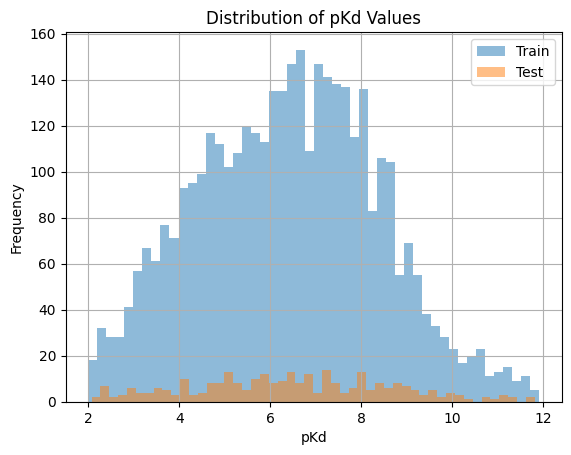

In [ ]:
# train_df['pkd'].hist(bins=50, alpha=0.5, label='Train')
# test_df['pkd'].hist(bins=50, alpha=0.5, label='Test')
# plt.xlabel('pKd')
# plt.ylabel('Frequency')
# plt.title('Distribution of pKd Values')
# plt.legend()
# plt.show()

In [7]:
train_df['seq'].str.len().describe()

count    3767.000000
mean      469.480754
std       471.564440
min        56.000000
25%       223.000000
50%       300.000000
75%       515.000000
max      4638.000000
Name: seq, dtype: float64

In [ ]:
from tokenizer import PDBBindDataset
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from model import HQDeepDTAF

# 1. Инициализируем датасеты, чтобы узнать реальные размеры словарей
train_ds = PDBBindDataset("pdbbind_train.csv")
test_ds = PDBBindDataset("pdbbind_core.csv")

# 2. Динамическая конфигурация
config = {
    # Берем размер словаря + 1 для запаса на Padding (0)
    'prot_vocab': max(train_ds.prot_vocab.values()) + 1,
    'lig_vocab': max(train_ds.lig_vocab.values()) + 1,
    'embed_dim': 128,
    'n_qubits': 9,
    'q_layers': 20,
    'cnn_mode': 'parallel',
    'max_prot': 1000,
    'max_lig': 128,
    'max_pock': 63
}

# 3. Инициализация модели и железа
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HQDeepDTAF(config).to(device)

# 4. Настройка обучения
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 5. Улучшенный цикл обучения
def train(epochs=100):
    print(f"Starting training on {device}...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for prot, lig, pock, y in train_loader:
            # Переносим всё на GPU/CPU
            prot, lig, pock, y = prot.to(device), lig.to(device), pock.to(device), y.to(device)
            
            optimizer.zero_grad()
            output = model(prot, lig, pock).view(-1)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        # Валидация в конце каждой эпохи (опционально, но полезно)
        avg_loss = total_loss / len(train_loader)
        # if i % 10 == 0:
        #     print(f"Batch {i}, Loss: {loss.item():.4f}")
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

train(100)